In [1]:
# Snotel vs Lidar Snow Depth Plots
# Started by Naheem

# Thomas Van Der Weide
# Modified 2026-01-14

In [2]:
from heapq import merge
import numpy as np
from metloom.pointdata import SnotelPointData
import geopandas as gpd
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from numpy.distutils.conv_template import header
import re
import glob
import rasterio
from concurrent.futures import ProcessPoolExecutor
from functools import partial

/tmp/ipykernel_16799/2326230766.py:11: DeprecationWarning: 

  `numpy.distutils` is deprecated since NumPy 1.23.0, as a result
  of the deprecation of `distutils` itself. It will be removed for
  Python >= 3.12. For older Python versions it will remain present.
  It is recommended to use `setuptools < 60.0` for those Python versions.
  For more details, see:
    https://numpy.org/devdocs/reference/distutils_status_migration.html 


  from numpy.distutils.conv_template import header


In [3]:
# pip install metloom

In [4]:
pt = SnotelPointData("637:ID:SNTL", "MCS")

# start data and end date
start_date = datetime(2019, 10, 1)
end_date = datetime(2026, 1, 13)
# Notice this is a list
variables = [pt.ALLOWED_VARIABLES.SNOWDEPTH]

# request the data
df = pt.get_daily_data(start_date, end_date, variables)
df.head(10)


,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource
datetime,site,,,,
2019-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-06 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-07 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-08 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-09 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS


In [5]:
snotel_point = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID

# get the daily data for the snotel site for the specified date range and variables
WY20 = snotel_point.get_daily_data(
    datetime(2019, 10, 1), datetime(2020, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [6]:

WY21 = snotel_point.get_daily_data(
    datetime(2020, 10, 1), datetime(2021, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [7]:

WY22 = snotel_point.get_daily_data(
    datetime(2021, 10, 1), datetime(2022, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [8]:

WY23 = snotel_point.get_daily_data(
    datetime(2022, 10, 1), datetime(2023, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [9]:

WY24 = snotel_point.get_daily_data(
    datetime(2023, 10, 1), datetime(2024, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [10]:

WY25 = snotel_point.get_daily_data(
    datetime(2024, 10, 1), datetime(2025, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)


In [11]:

WY26 = snotel_point.get_daily_data(
    datetime(2025, 10, 1), datetime(2026, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [12]:
WY20.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 367 entries, (Timestamp('2019-10-01 08:00:00+0000', tz='UTC'), '637:ID:SNTL') to (Timestamp('2020-10-01 08:00:00+0000', tz='UTC'), '637:ID:SNTL')
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   geometry         367 non-null    geometry
 1   SNOWDEPTH        367 non-null    float64 
 2   SNOWDEPTH_units  367 non-null    object  
 3   datasource       367 non-null    object  
dtypes: float64(1), geometry(1), object(2)
memory usage: 23.7+ KB


In [13]:
WYS = [WY20,WY21,WY22,WY23,WY24,WY25,WY26]
merged = gpd.GeoDataFrame(pd.concat(WYS, ignore_index=False))

merged.head()

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource
datetime,site,,,,
2019-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS
2019-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS


In [14]:
df["SNOWDEPTH (m)"] = df["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
df.head()

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2019-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2019-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2019-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2019-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2019-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0


In [15]:
#df.to_csv("snotel_data.csv") # save the data to a csv file
#df.head()

In [16]:
print(df.index.names)

['datetime', 'site']


In [17]:
dates = df.index.get_level_values('datetime')
month = dates.month
mask = ((month >= 10) | (month <= 5))
df_filtered = df.loc[mask]

df_filtered.head()
df_filtered.to_csv("filtered_SNOTEL.csv")

In [18]:
print(df_filtered.index.names)

['datetime', 'site']


In [19]:
dates = df_filtered.index.get_level_values('datetime')
snowdepth = df_filtered['SNOWDEPTH (m)']

In [20]:
LiDAR_dates = [
    '2020-02-09', '2021-03-15',  # added
    '2022-02-17', '2022-03-17', '2022-04-07',
    '2022-12-08', '2023-02-09', '2023-03-16',
    '2023-04-05', '2023-11-13', '2023-12-28', 
    '2024-01-15', '2024-02-13', '2024-03-15',
    '2024-04-18', '2025-01-13', '2025-01-29',
    '2025-04-04', '2025-05-01'
]

LiDAR_dates = pd.to_datetime(LiDAR_dates)

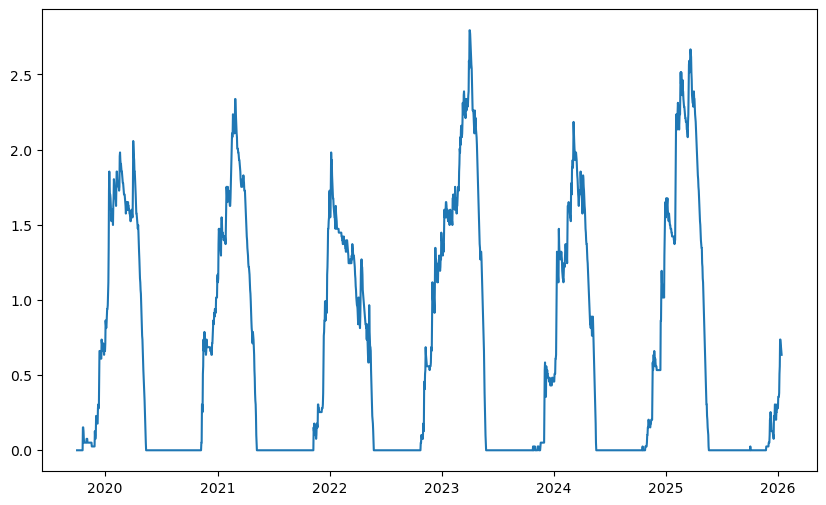

In [21]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, linestyle='-')

In [22]:
dates

DatetimeIndex(['2019-10-01 08:00:00+00:00', '2019-10-02 08:00:00+00:00',
               '2019-10-03 08:00:00+00:00', '2019-10-04 08:00:00+00:00',
               '2019-10-05 08:00:00+00:00', '2019-10-06 08:00:00+00:00',
               '2019-10-07 08:00:00+00:00', '2019-10-08 08:00:00+00:00',
               '2019-10-09 08:00:00+00:00', '2019-10-10 08:00:00+00:00',
               ...
               '2026-01-04 08:00:00+00:00', '2026-01-05 08:00:00+00:00',
               '2026-01-06 08:00:00+00:00', '2026-01-07 08:00:00+00:00',
               '2026-01-08 08:00:00+00:00', '2026-01-09 08:00:00+00:00',
               '2026-01-10 08:00:00+00:00', '2026-01-11 08:00:00+00:00',
               '2026-01-12 08:00:00+00:00', '2026-01-13 08:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='datetime', length=1565, freq=None)

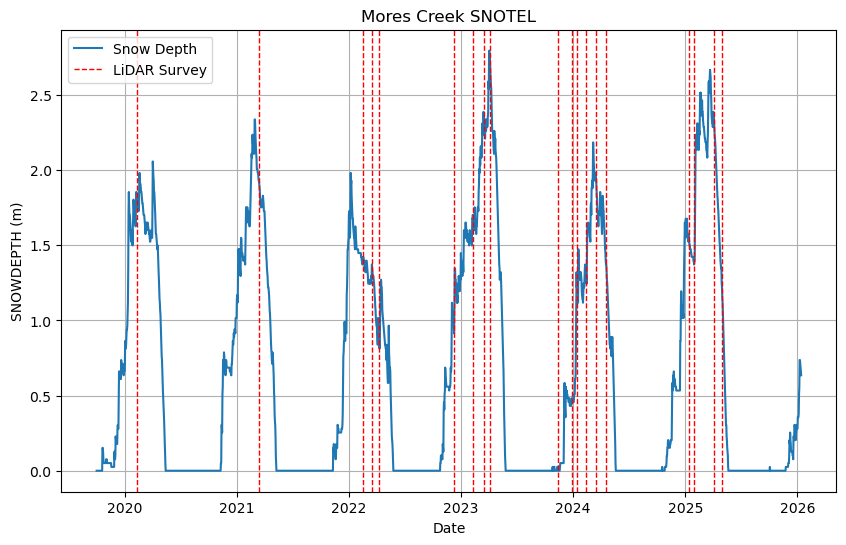

In [23]:
    # Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, linestyle='-', label='Snow Depth')

for i, d in enumerate(LiDAR_dates):
        plt.axvline(
        d,
        color='red',
        linestyle='--',
        linewidth=1,
        label='LiDAR Survey' if i == 0 else None
    )

plt.xlabel('Date')
plt.ylabel('SNOWDEPTH (m)')
plt.title('Mores Creek SNOTEL')
plt.grid(True)
plt.legend()

# Optional: limit x-axis to 5 labels
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))

plt.show()


In [24]:
dates = df.index.get_level_values('datetime')
start = pd.Timestamp('2022-10-01 08:00:00+00:00')
end   = pd.Timestamp('2023-05-30 08:00:00+00:00')

mask = (dates >= start) & (dates <= end)

WY2023 = df.loc[mask]

WY2023

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2022-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2022-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2022-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2022-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2022-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
...,...,...,...,...,...,...
2023-05-26 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2023-05-27 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2023-05-28 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0


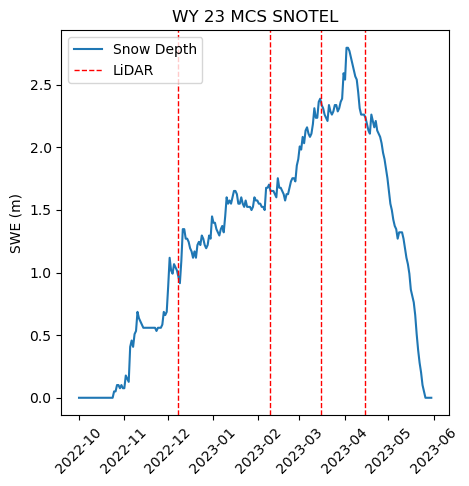

In [25]:
##'2022-12-08', '2023-02-09', '2023-03-16', 2023-11-13', '2023-12-28',  # fixed 12-38 → 12-28'2024-01-15', '2024-02-13', '2024-03-15', '2024-04-28',

dates = WY2023.index.get_level_values('datetime')
snowdepth = WY2023['SNOWDEPTH (m)']

Wy23 = fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dates, snowdepth, label='Snow Depth')
ax.set_title("WY 23 MCS SNOTEL")
ax.set_ylabel("SWE (m)")

# Add vertical lines, label only once
vlines = [pd.Timestamp("2022-12-08"), pd.Timestamp("2023-02-09"), pd.Timestamp("2023-03-16"), pd.Timestamp("2023-04-15")]
for i, dt in enumerate(vlines):
    if i == 0:
        ax.axvline(dt, color="red", linestyle="--", linewidth=1, label='LiDAR')
    else:
        ax.axvline(dt, color="red", linestyle="--", linewidth=1)

ax.tick_params(axis='x', labelrotation=45)
ax.legend()
plt.show()


In [26]:
dates = df.index.get_level_values('datetime')
start = pd.Timestamp('2023-10-01 08:00:00+00:00')
end   = pd.Timestamp('2024-05-30 08:00:00+00:00')

mask = (dates >= start) & (dates <= end)

WY2024 = df.loc[mask]

WY2024

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2023-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2023-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2023-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2023-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2023-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
...,...,...,...,...,...,...
2024-05-26 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2024-05-27 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2024-05-28 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0


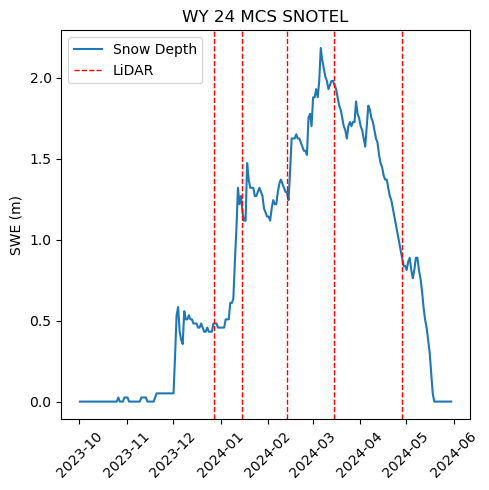

In [27]:
dates = WY2024.index.get_level_values('datetime')
snowdepth = WY2024['SNOWDEPTH (m)']

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dates, snowdepth, label='Snow Depth')
ax.set_title("WY 24 MCS SNOTEL")
ax.set_ylabel("SWE (m)")

vlines = [
    pd.Timestamp("2023-12-28"),
    pd.Timestamp("2024-01-15"),
    pd.Timestamp("2024-02-13"),
    pd.Timestamp("2024-03-15"),
    pd.Timestamp("2024-04-28"),
]

for i, dt in enumerate(vlines):
    ax.axvline(
        dt,
        color="red",
        linestyle="--",
        linewidth=1,
        label="LiDAR" if i == 0 else None,
    )

ax.tick_params(axis='x', labelrotation=45)
ax.legend()
plt.tight_layout()
plt.show()


In [28]:
dates = df.index.get_level_values('datetime')
start = pd.Timestamp('2024-10-01 08:00:00+00:00')
end   = pd.Timestamp('2025-05-30 08:00:00+00:00')

mask = (dates >= start) & (dates <= end)

WY2025 = df.loc[mask]

WY2025

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2024-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2024-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2024-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2024-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2024-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
...,...,...,...,...,...,...
2025-05-26 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2025-05-27 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0
2025-05-28 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.932 6090),0.0,in,NRCS,0.0


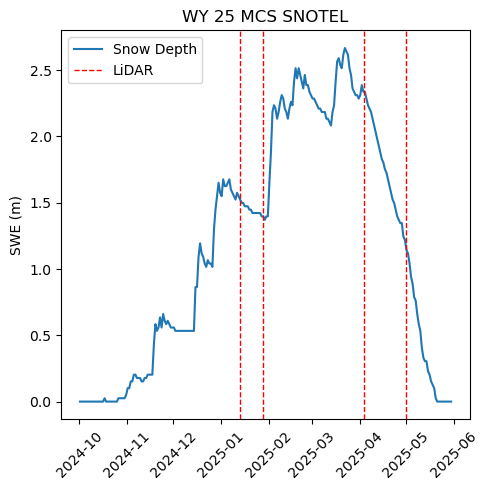

In [29]:
dates = WY2025.index.get_level_values('datetime')
snowdepth = WY2025['SNOWDEPTH (m)']

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dates, snowdepth, label='Snow Depth')
ax.set_title("WY 25 MCS SNOTEL")
ax.set_ylabel("SWE (m)")

vlines = [
    pd.Timestamp("2025-01-13"),
    pd.Timestamp("2025-01-28"),
    pd.Timestamp("2025-04-04"),
    pd.Timestamp("2025-05-01"),
]

for i, dt in enumerate(vlines):
    ax.axvline(
        dt,
        color="red",
        linestyle="--",
        linewidth=1,
        label="LiDAR" if i == 0 else None,
    )

ax.tick_params(axis='x', labelrotation=45)
ax.legend()
plt.tight_layout()
plt.show()
